### **GIẢI THUẬT 1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY**

### **2.1.2. Bài làm mẫu**
Bài toán 1: Xây dựng cây quyết định và rừng cây với dữ liệu lấy từ https://www.kaggle.com/datasets/deceneu/default-of-credit-card-clients

**Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn**

1.Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [5]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

2.Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải
quyết

In [7]:
df = pd.read_csv("C:/Users/Admin/OneDrive/Documents/bt ptdl/bt_tuan_ptdl/da06_baitoanphanlop_Nguyễn Hoàng Thanh Tâm_3122410371/default_of_credit_card_clients.csv") #Load the cleaned data
features_response = df.columns.tolist() #Get a list of column names
#Make a list of columns to remove that aren't features or the response variable
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',\
'PAY_4', 'PAY_5', 'PAY_6',\
'EDUCATION_CAT', 'graduate school',\
'high school', 'none',\
'others', 'university']
features_response = [item for item in features_response if item not
in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

3.Chuẩn bị dữ liệu cho tập train và tập test

In [8]:
from sklearn.model_selection import train_test_split
from sklearn import tree
#Split the data into training and testing sets using the same random seed
X_train, X_test, y_train, y_test = \
train_test_split(df[features_response[:-1]].values,
df['default payment next month'].values,
test_size=0.2, random_state=24)

4.Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn

In [9]:
# the tree will grow to a depth of at most 2
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


5.Hiển thị cây quyết định với package graphviz

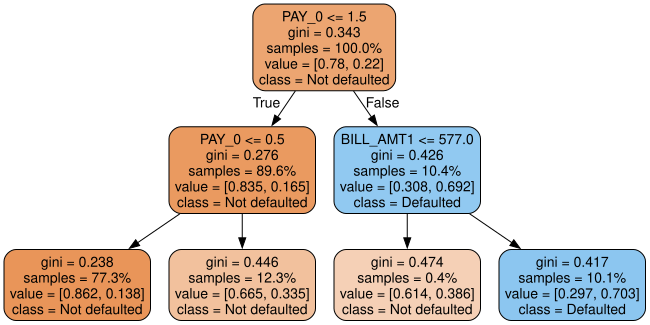

In [10]:
dot_data = tree.export_graphviz(dt,
out_file=None,
filled=True,
rounded=True,
feature_names=\
features_response[:-1],
proportion=True,
class_names=['Not defaulted', 'Defaulted'])
graph = graphviz.Source(dot_data)
graph

**Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau**

1.Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

2.Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu

In [11]:
from sklearn.model_selection import GridSearchCV
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]} #parameters
dt = tree.DecisionTreeClassifier() #tree modal
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
n_jobs=None, refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True) # cv is the best model.
cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


**scoring = 'roc_auc': the ROC AUC metric**

Trong quá trình đánh giá mô hình phân loại, việc lựa chọn thước đo phù hợp đóng vai trò quan trọng trong việc phản ánh chính xác hiệu quả của mô hình. Tham số scoring = 'roc_auc' sử dụng chỉ số AUC (Area Under the Curve) của đường cong ROC (Receiver Operating Characteristic) làm tiêu chí đánh giá.

Chỉ số AUC-ROC đo lường khả năng phân biệt giữa hai lớp của mô hình phân loại. Giá trị AUC dao động từ 0 đến 1, trong đó giá trị càng gần 1 thể hiện mô hình có khả năng phân biệt tốt. AUC bằng 0.5 biểu thị mô hình không có khả năng phân biệt, tương đương với việc dự đoán ngẫu nhiên.

Ưu điểm của chỉ số AUC-ROC là ít bị ảnh hưởng bởi sự mất cân bằng lớp trong dữ liệu, do đó được sử dụng phổ biến trong các bài toán phân loại nhị phân.

**cv = 4: 4-fold cross-validation**

Tham số cv = 4 quy định số lần kiểm định chéo (cross-validation) là 4. Dữ liệu huấn luyện được chia thành 4 phần bằng nhau. Trong mỗi vòng lặp, mô hình được huấn luyện trên 3 phần dữ liệu và đánh giá trên phần còn lại. Quá trình này lặp lại 4 lần để đảm bảo mỗi phần dữ liệu đều được sử dụng làm tập kiểm định đúng một lần.

Phương pháp kiểm định chéo giúp giảm thiểu sự phụ thuộc vào một lần chia dữ liệu duy nhất, từ đó cung cấp đánh giá ổn định và đáng tin cậy hơn về hiệu năng mô hình. Kết quả cuối cùng được tính bằng giá trị trung bình của các lần kiểm định, góp phần hạn chế sai lệch do phân bố dữ liệu không đồng đều.

**return_train_score = true: để đánh giá bias và variance**

Tham số return_train_score = True cho phép ghi nhận đồng thời điểm số trên tập huấn luyện và tập kiểm định trong quá trình đánh giá mô hình. Thông tin này giúp phân tích mức độ chệch (bias) và phương sai (variance) của mô hình.

Nếu điểm số trên tập huấn luyện và tập kiểm định đều thấp, mô hình có khả năng đang gặp hiện tượng underfitting, thể hiện độ chệch cao. Ngược lại, nếu điểm số trên tập huấn luyện cao nhưng trên tập kiểm định thấp, mô hình có khả năng overfitting, thể hiện phương sai cao. Trong trường hợp điểm số của hai tập tương đồng và ở mức cao, mô hình được xem là có khả năng tổng quát tốt.

Việc sử dụng tham số này hỗ trợ quá trình lựa chọn và tinh chỉnh mô hình, đảm bảo đạt được sự cân bằng giữa độ chính xác trên tập huấn luyện và khả năng khái quát hóa trên dữ liệu kiểm định.

3.Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_31108\1478637665.py:8: SyntaxWarning: invalid escape sequence '\p'
  label='Mean $\pm$ 1 SE training scores')
C:\Users\Admin\AppData\Local\Temp\ipykernel_31108\1478637665.py:12: SyntaxWarning: invalid escape sequence '\p'
  label='Mean $\pm$ 1 SE testing scores')


Text(0, 0.5, 'ROC AUC')

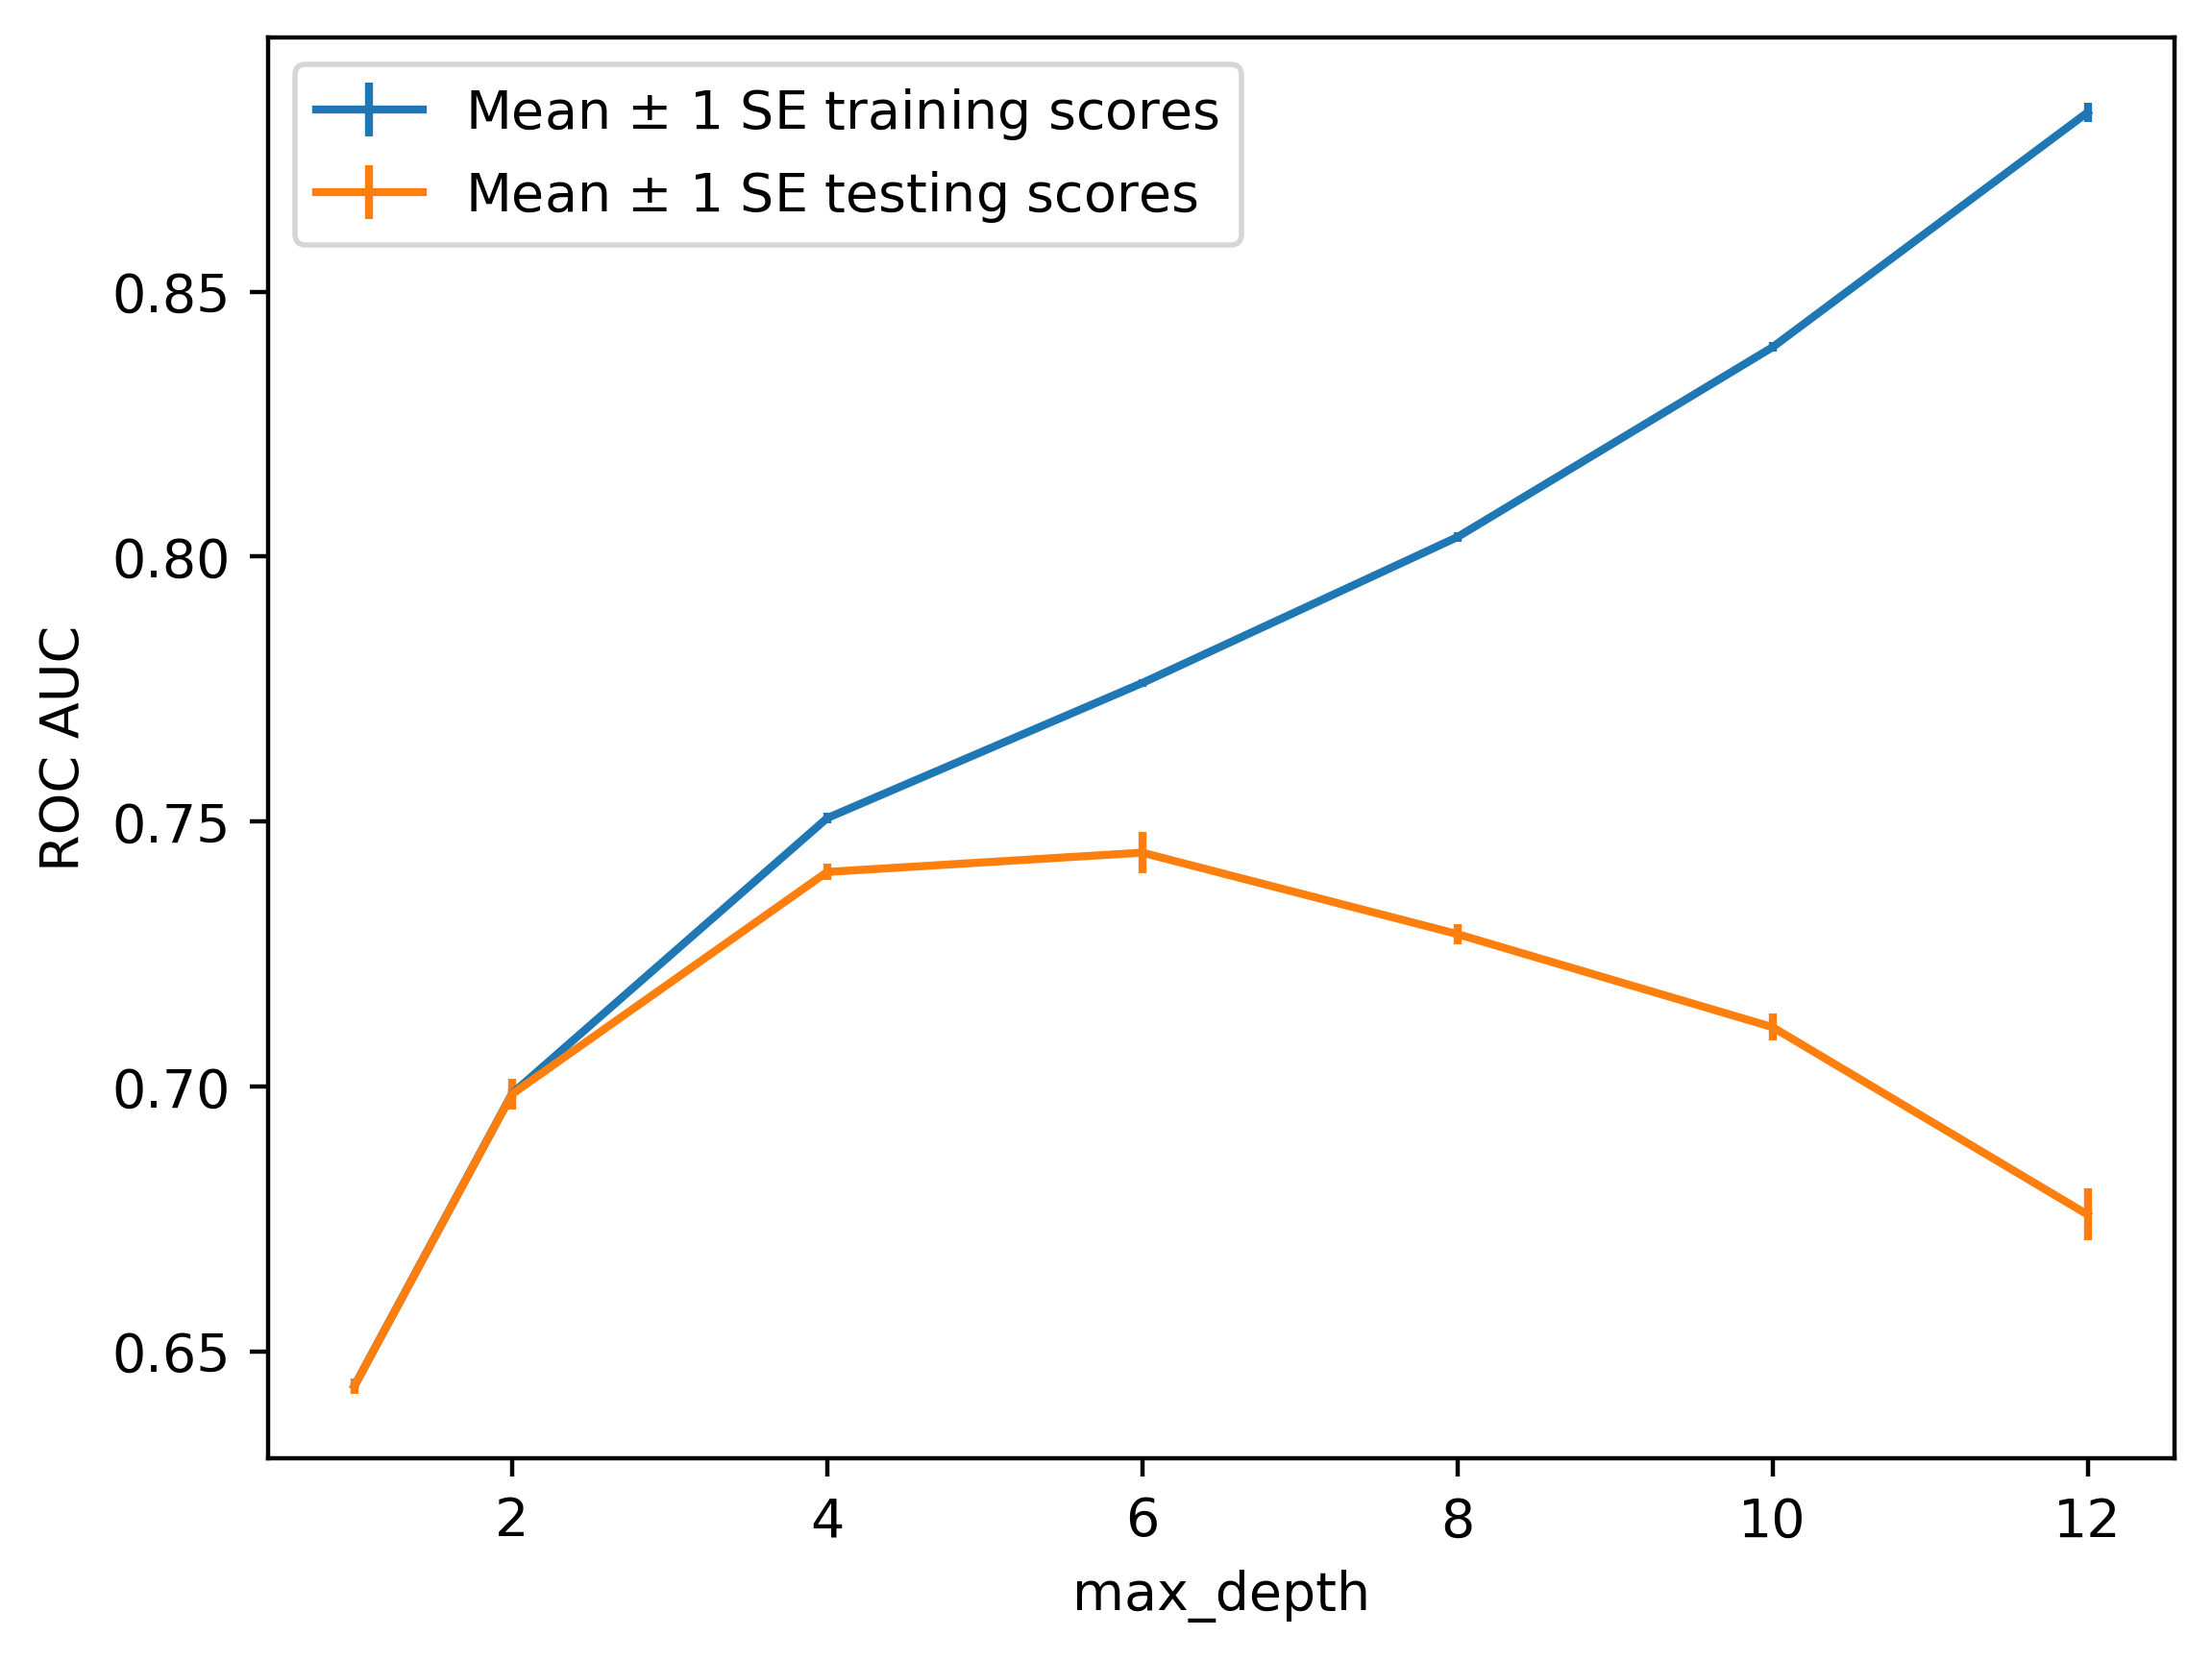

In [12]:
cv_results_df = pd.DataFrame(cv.cv_results_)
#View the names of the remaining columns in the results DataFrame
cv_results_df.columns
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_train_score'],
yerr=cv_results_df['std_train_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_test_score'],
yerr=cv_results_df['std_test_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')

**Nhiệm vụ 3: Xây dựng rừng cây (random forest)**

1.Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

2.Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier\
(n_estimators=10, criterion='gini', max_depth=3,
min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
bootstrap=True, oob_score=False, n_jobs=None,
random_state=4, verbose=0, warm_start=False, class_weight=None)

3.Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [16]:
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
scoring='roc_auc', n_jobs=None,
refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,60


4.Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_31108\1889697650.py:12: SyntaxWarning: invalid escape sequence '\p'
  axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')


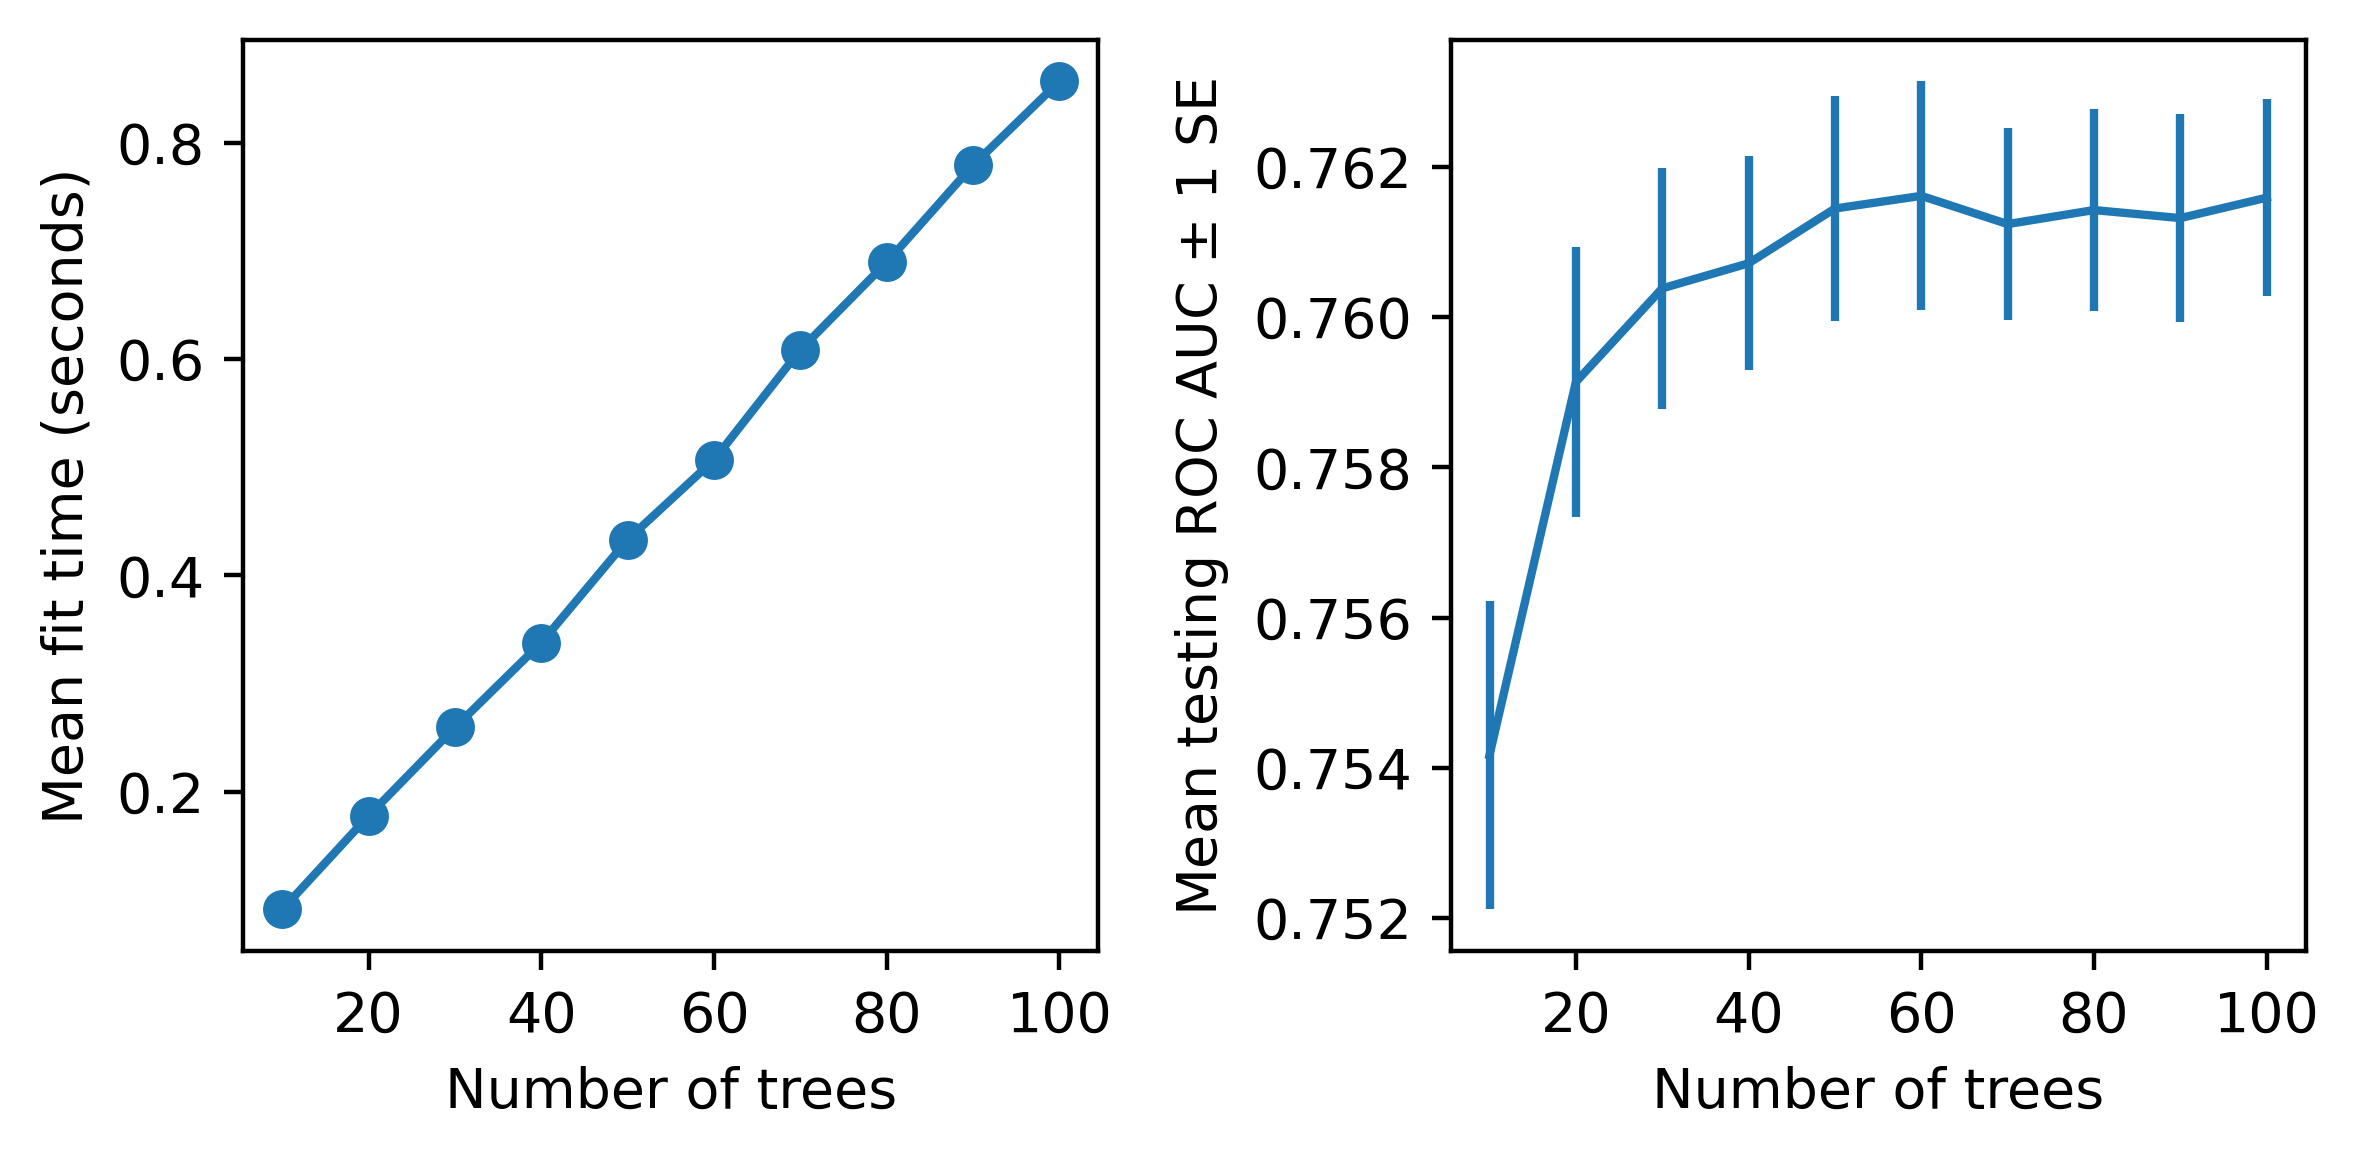

In [17]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')
plt.tight_layout()

5.Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham
số tốt nhất

<Axes: >

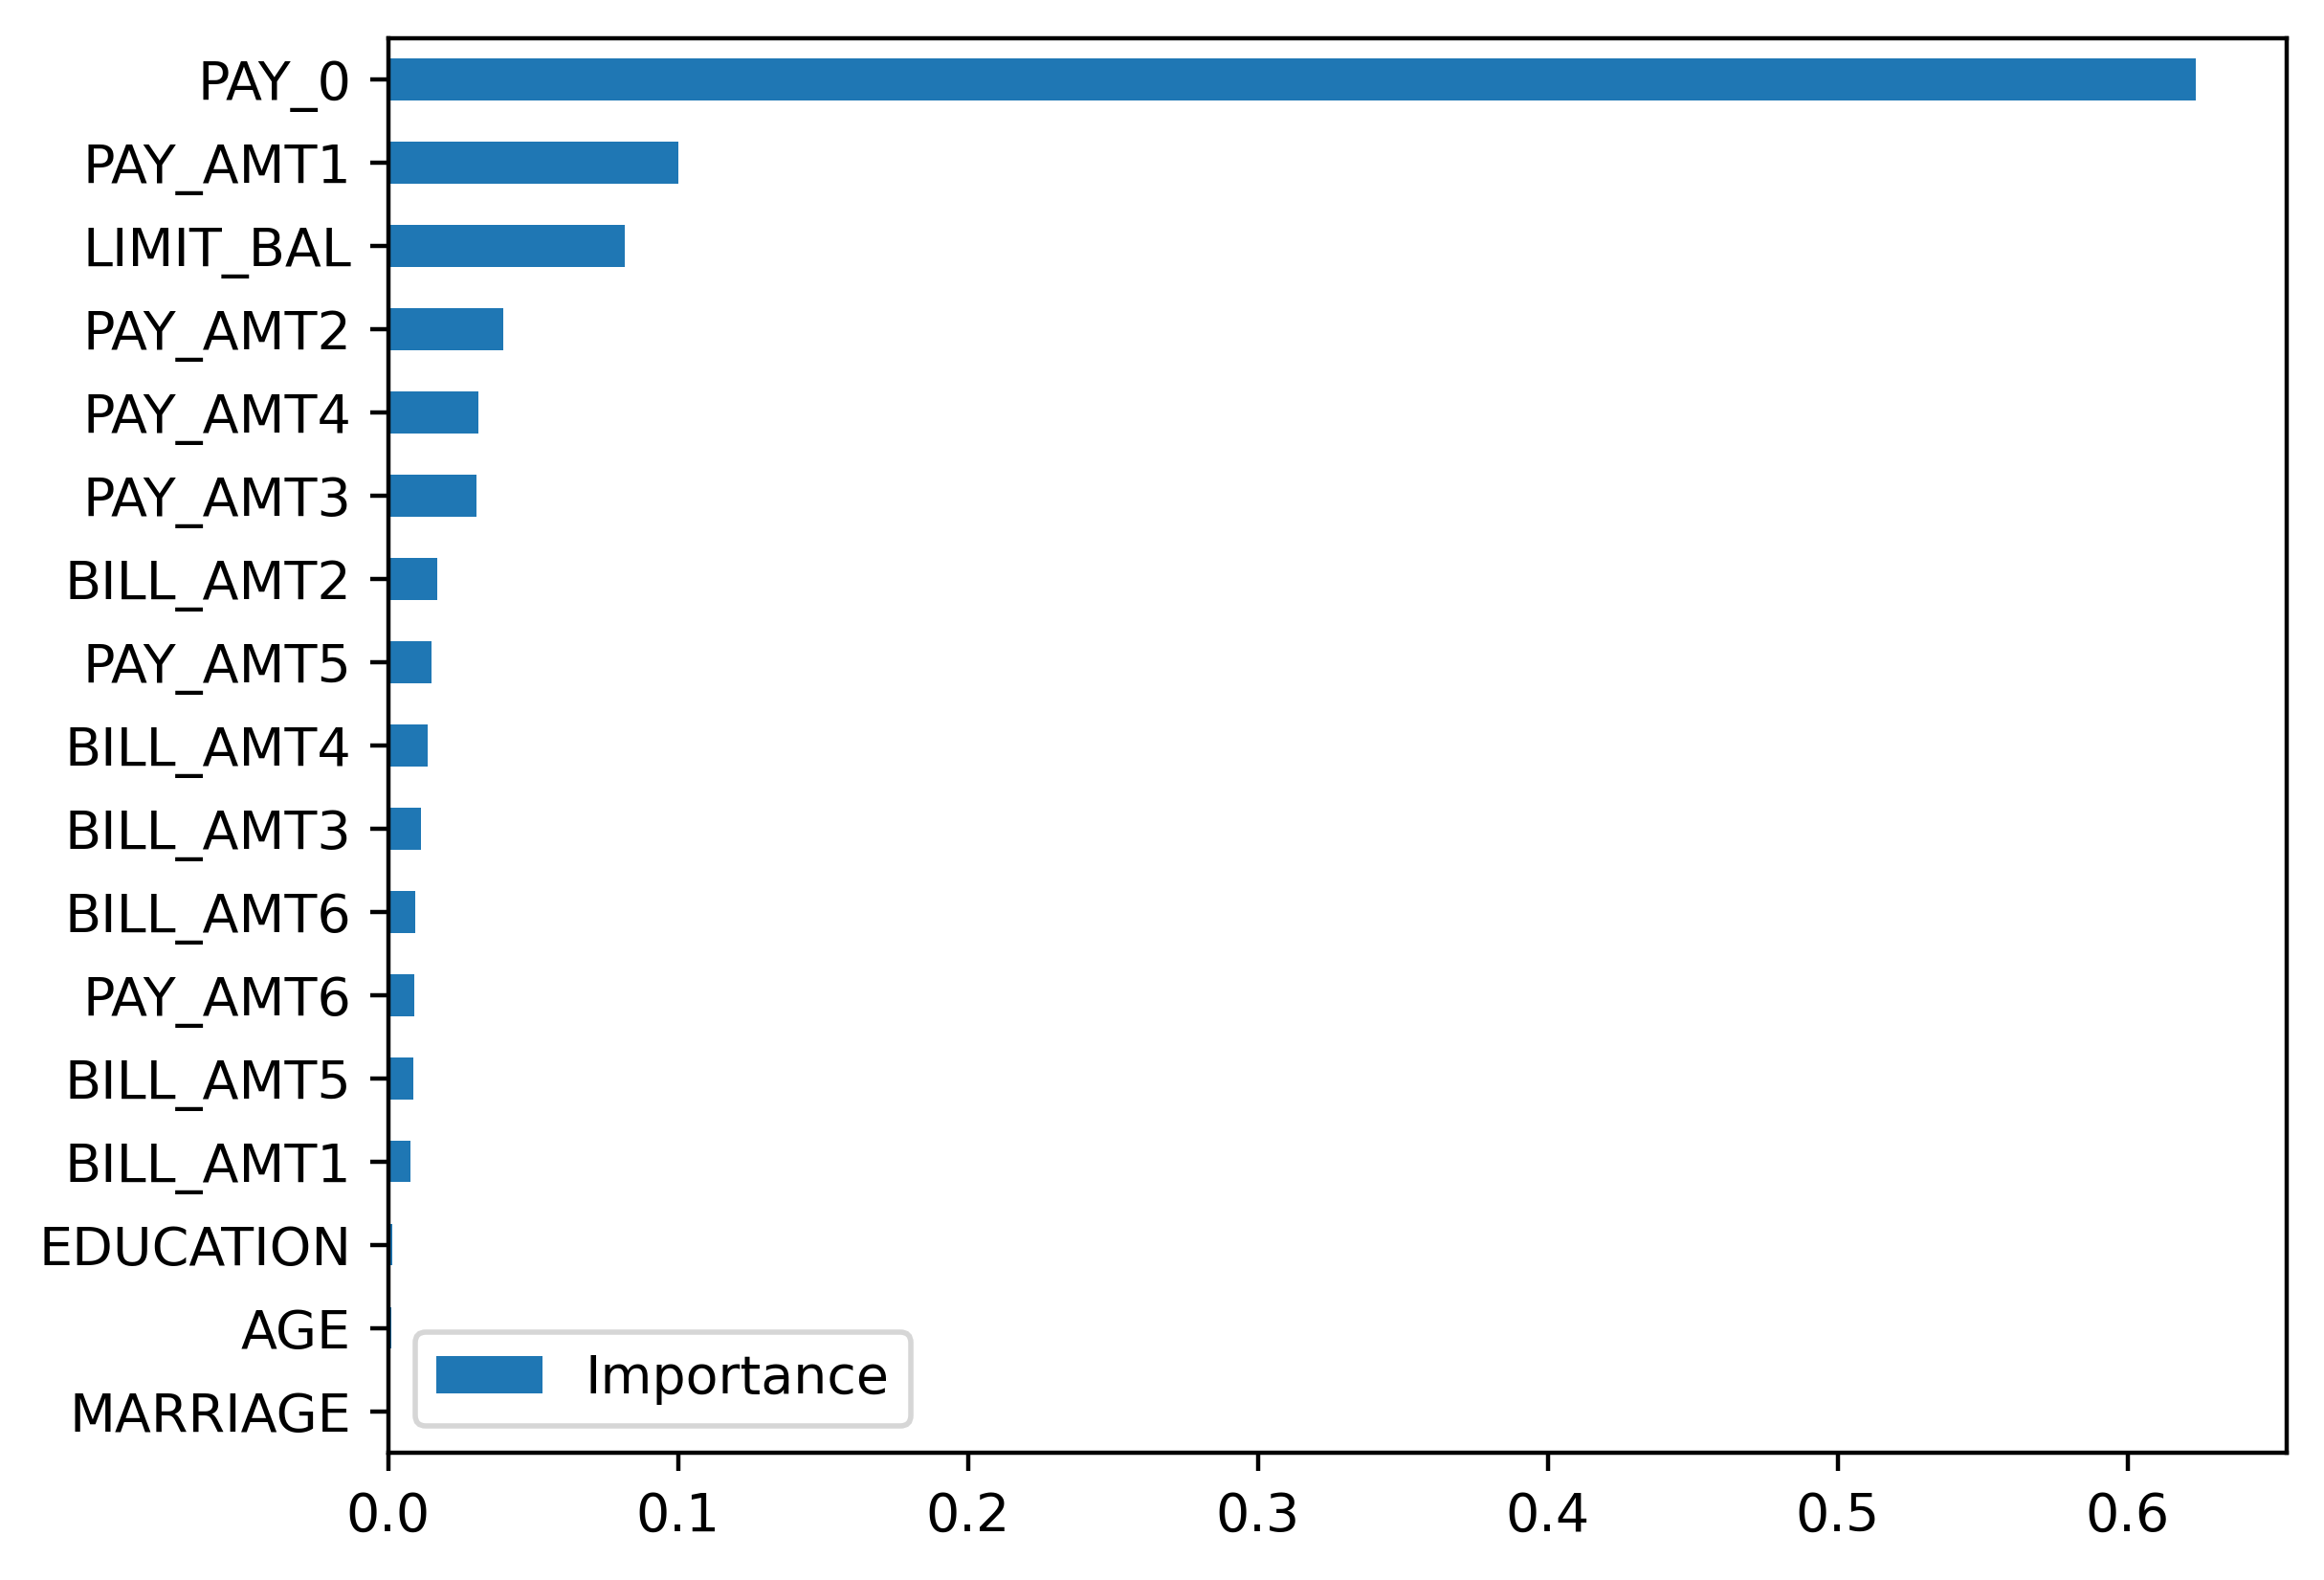

In [18]:
# {'n_estimators': 50}
cv_rf_ex.best_params_
# the feature names and importances
feat_imp_df = pd.DataFrame({
'Importance':cv_rf_ex.best_estimator_.feature_importances_},
index=features_response[:-1])
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()

### **2.1.3. Bài tập thực hành 1**

Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic lấy từ https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset

**Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn**

1.Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [19]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

2.Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải quyết

In [20]:
df = pd.read_csv("C:/Users/Admin/OneDrive/Documents/bt ptdl/bt_tuan_ptdl/da06_baitoanphanlop_Nguyễn Hoàng Thanh Tâm_3122410371/titanic/train.csv") #Load the cleaned data
features_response = df.columns.tolist() #Get a list of column names
#Make a list of columns to remove that aren't features or the response variable
items_to_remove = ['PassengerId', 'Name', 'Ticket', 'Cabin']
features_response = [item for item in features_response if item not
in items_to_remove]
features_response

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

3.Chuẩn bị dữ liệu cho tập train và tập test

In [22]:
# Tách target và features
X = df[features_response].drop('Survived', axis=1)
y = df['Survived']

# Mã hóa biến phân loại
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

# Xử lý giá trị thiếu
X = X.fillna(X.median(numeric_only=True))

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24
)

4.Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn

In [23]:
dt = tree.DecisionTreeClassifier(max_depth=2, random_state=24)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


5.Hiển thị cây quyết định với package graphviz

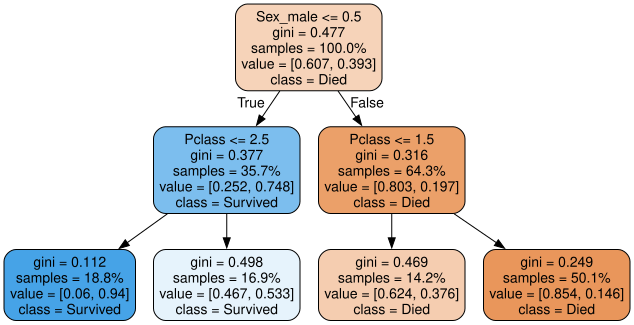

In [24]:
dot_data = tree.export_graphviz(
    dt,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    proportion=True,
    class_names=['Died', 'Survived']
)
graph = graphviz.Source(dot_data)
graph


**Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau**

1.Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

2.Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu

In [25]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]}  # các giá trị thử nghiệm
dt_gs = tree.DecisionTreeClassifier(random_state=24)

cv = GridSearchCV(
    dt_gs,
    param_grid=params,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


,estimator,DecisionTreeC...ndom_state=24)
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


3.Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

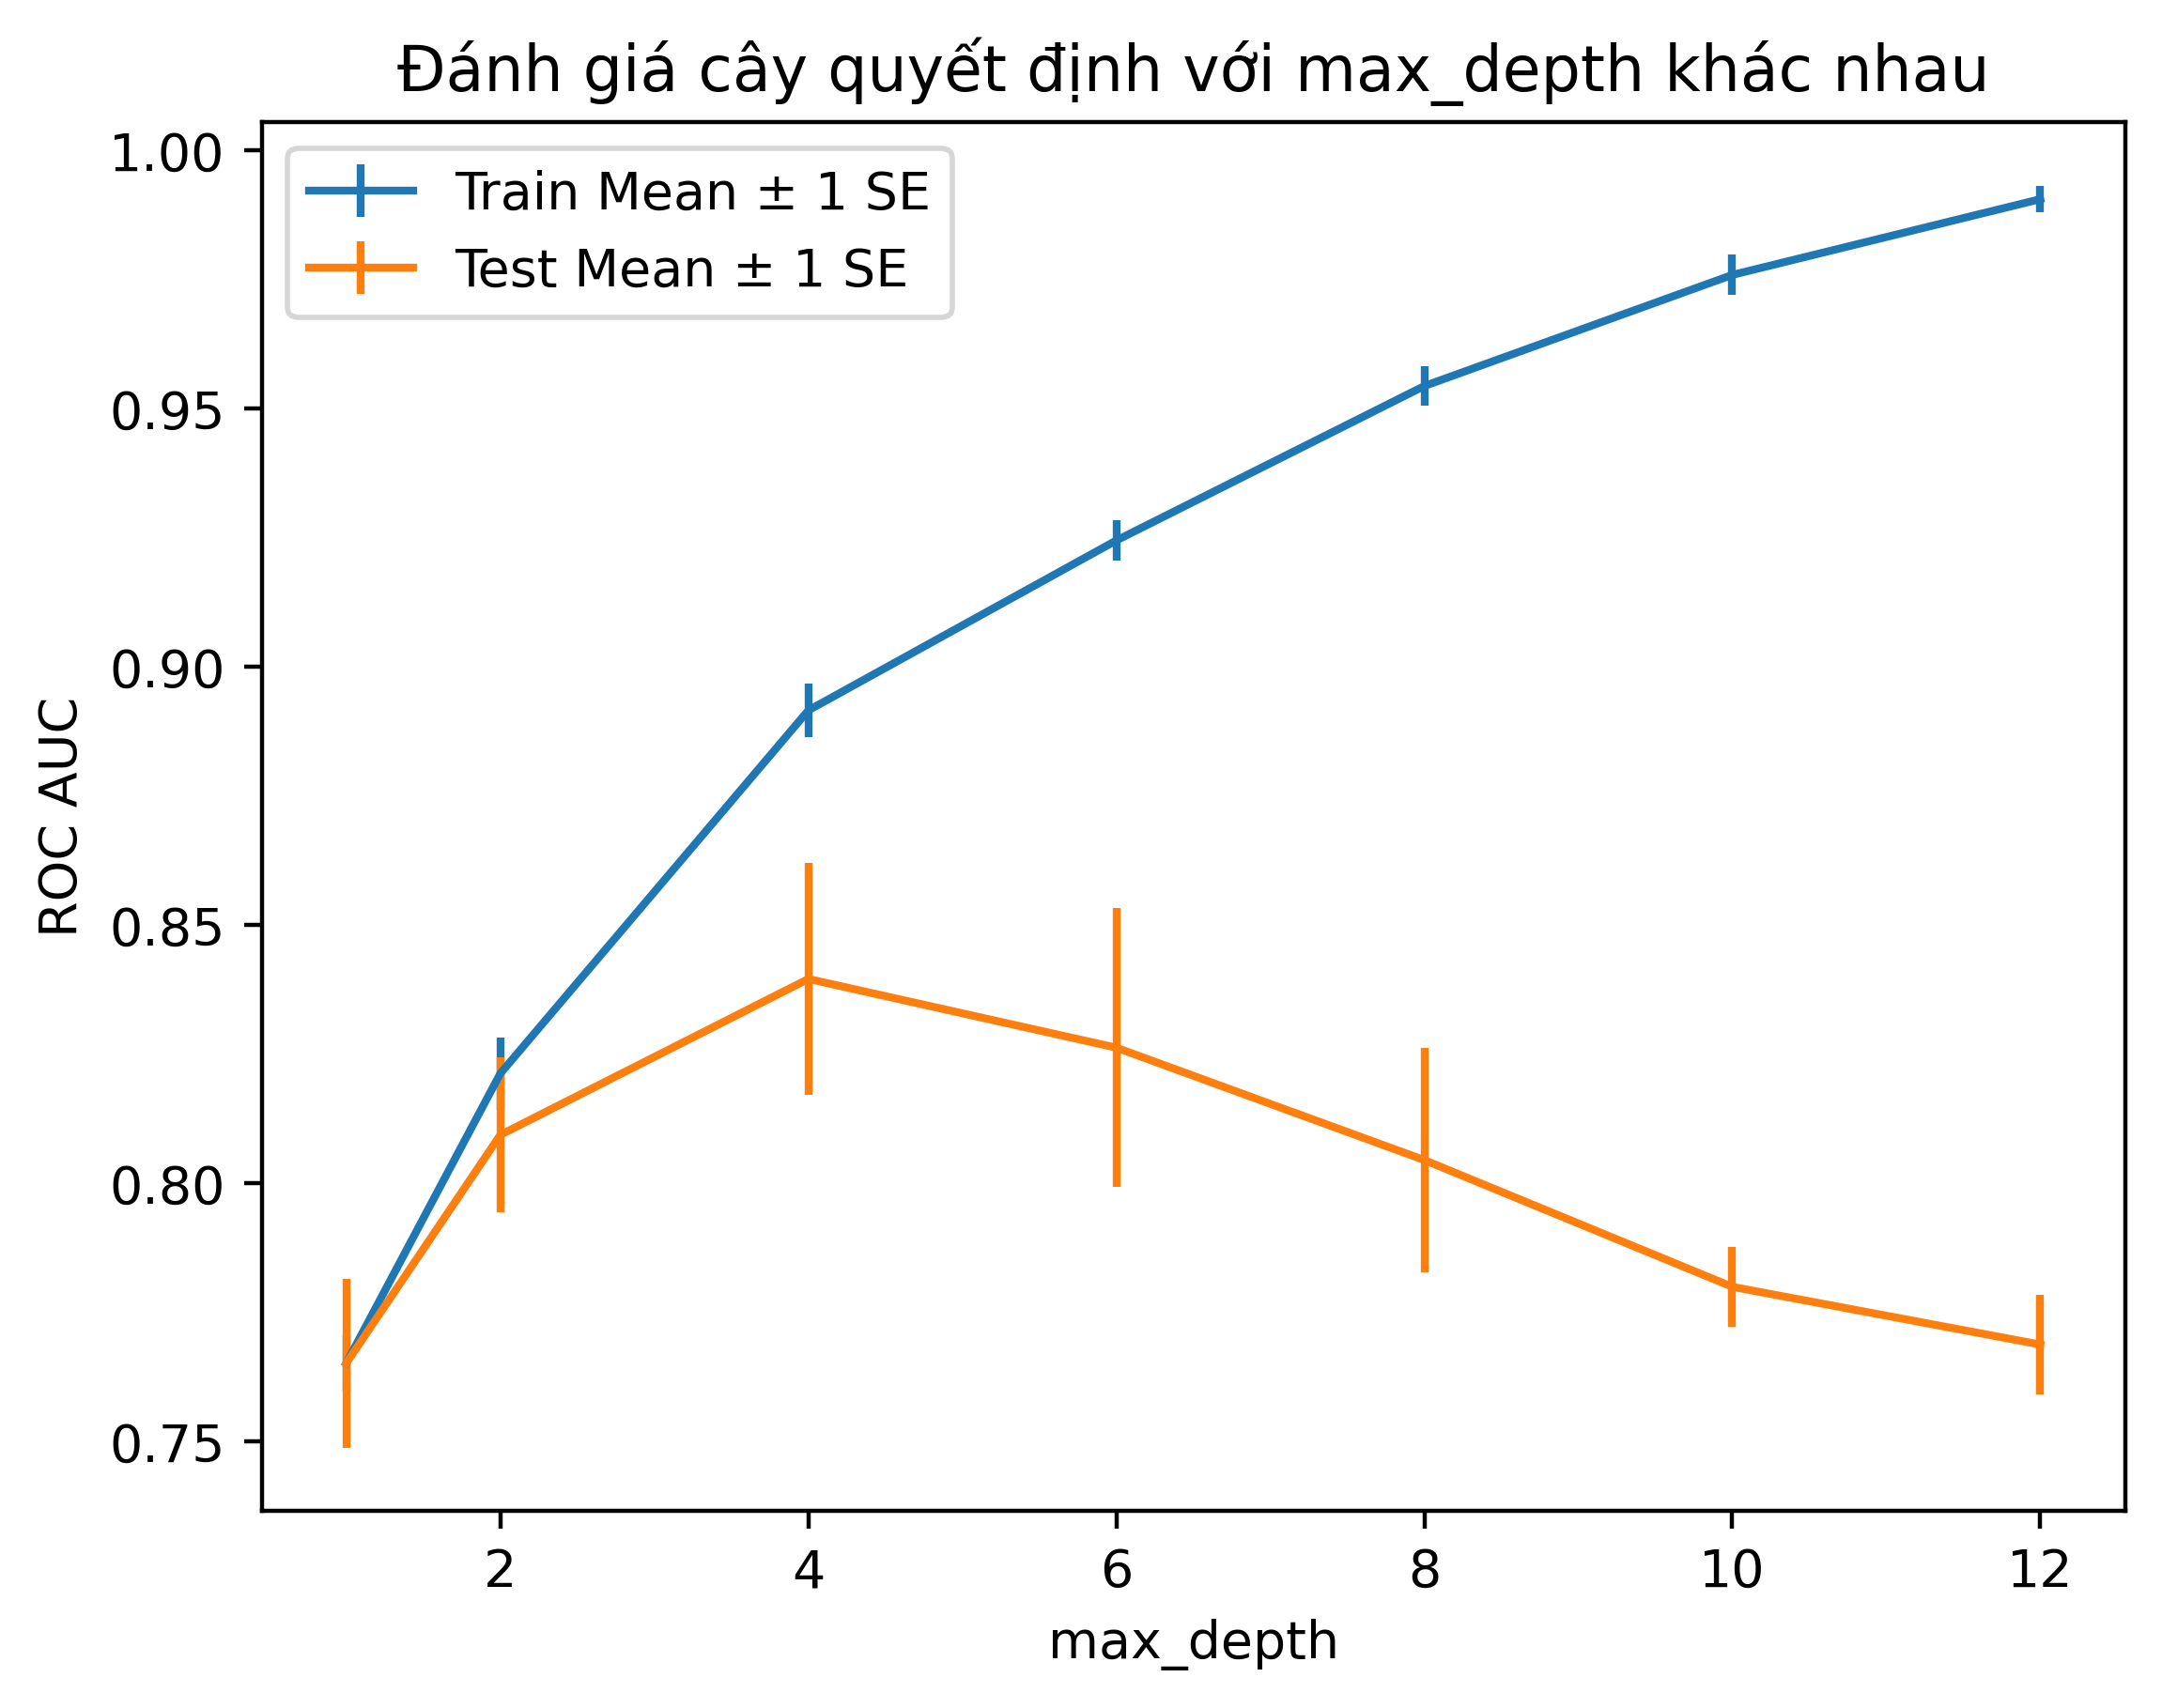

Best max_depth: {'max_depth': 4}


In [26]:
cv_results_df = pd.DataFrame(cv.cv_results_)

ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_train_score'],
            yerr=cv_results_df['std_train_score']/np.sqrt(4),
            label='Train Mean ± 1 SE')
ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_test_score'],
            yerr=cv_results_df['std_test_score']/np.sqrt(4),
            label='Test Mean ± 1 SE')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Đánh giá cây quyết định với max_depth khác nhau')
plt.show()

print("Best max_depth:", cv.best_params_)


**Nhiệm vụ 3: Xây dựng rừng cây (random forest)**

1.Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

2.Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=10,
    criterion='gini',
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=4
)


3.Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [28]:
rf_params_ex = {'n_estimators': list(range(10, 110, 10))}

cv_rf_ex = GridSearchCV(
    rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv_rf_ex.fit(X_train, y_train)


Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


4.Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

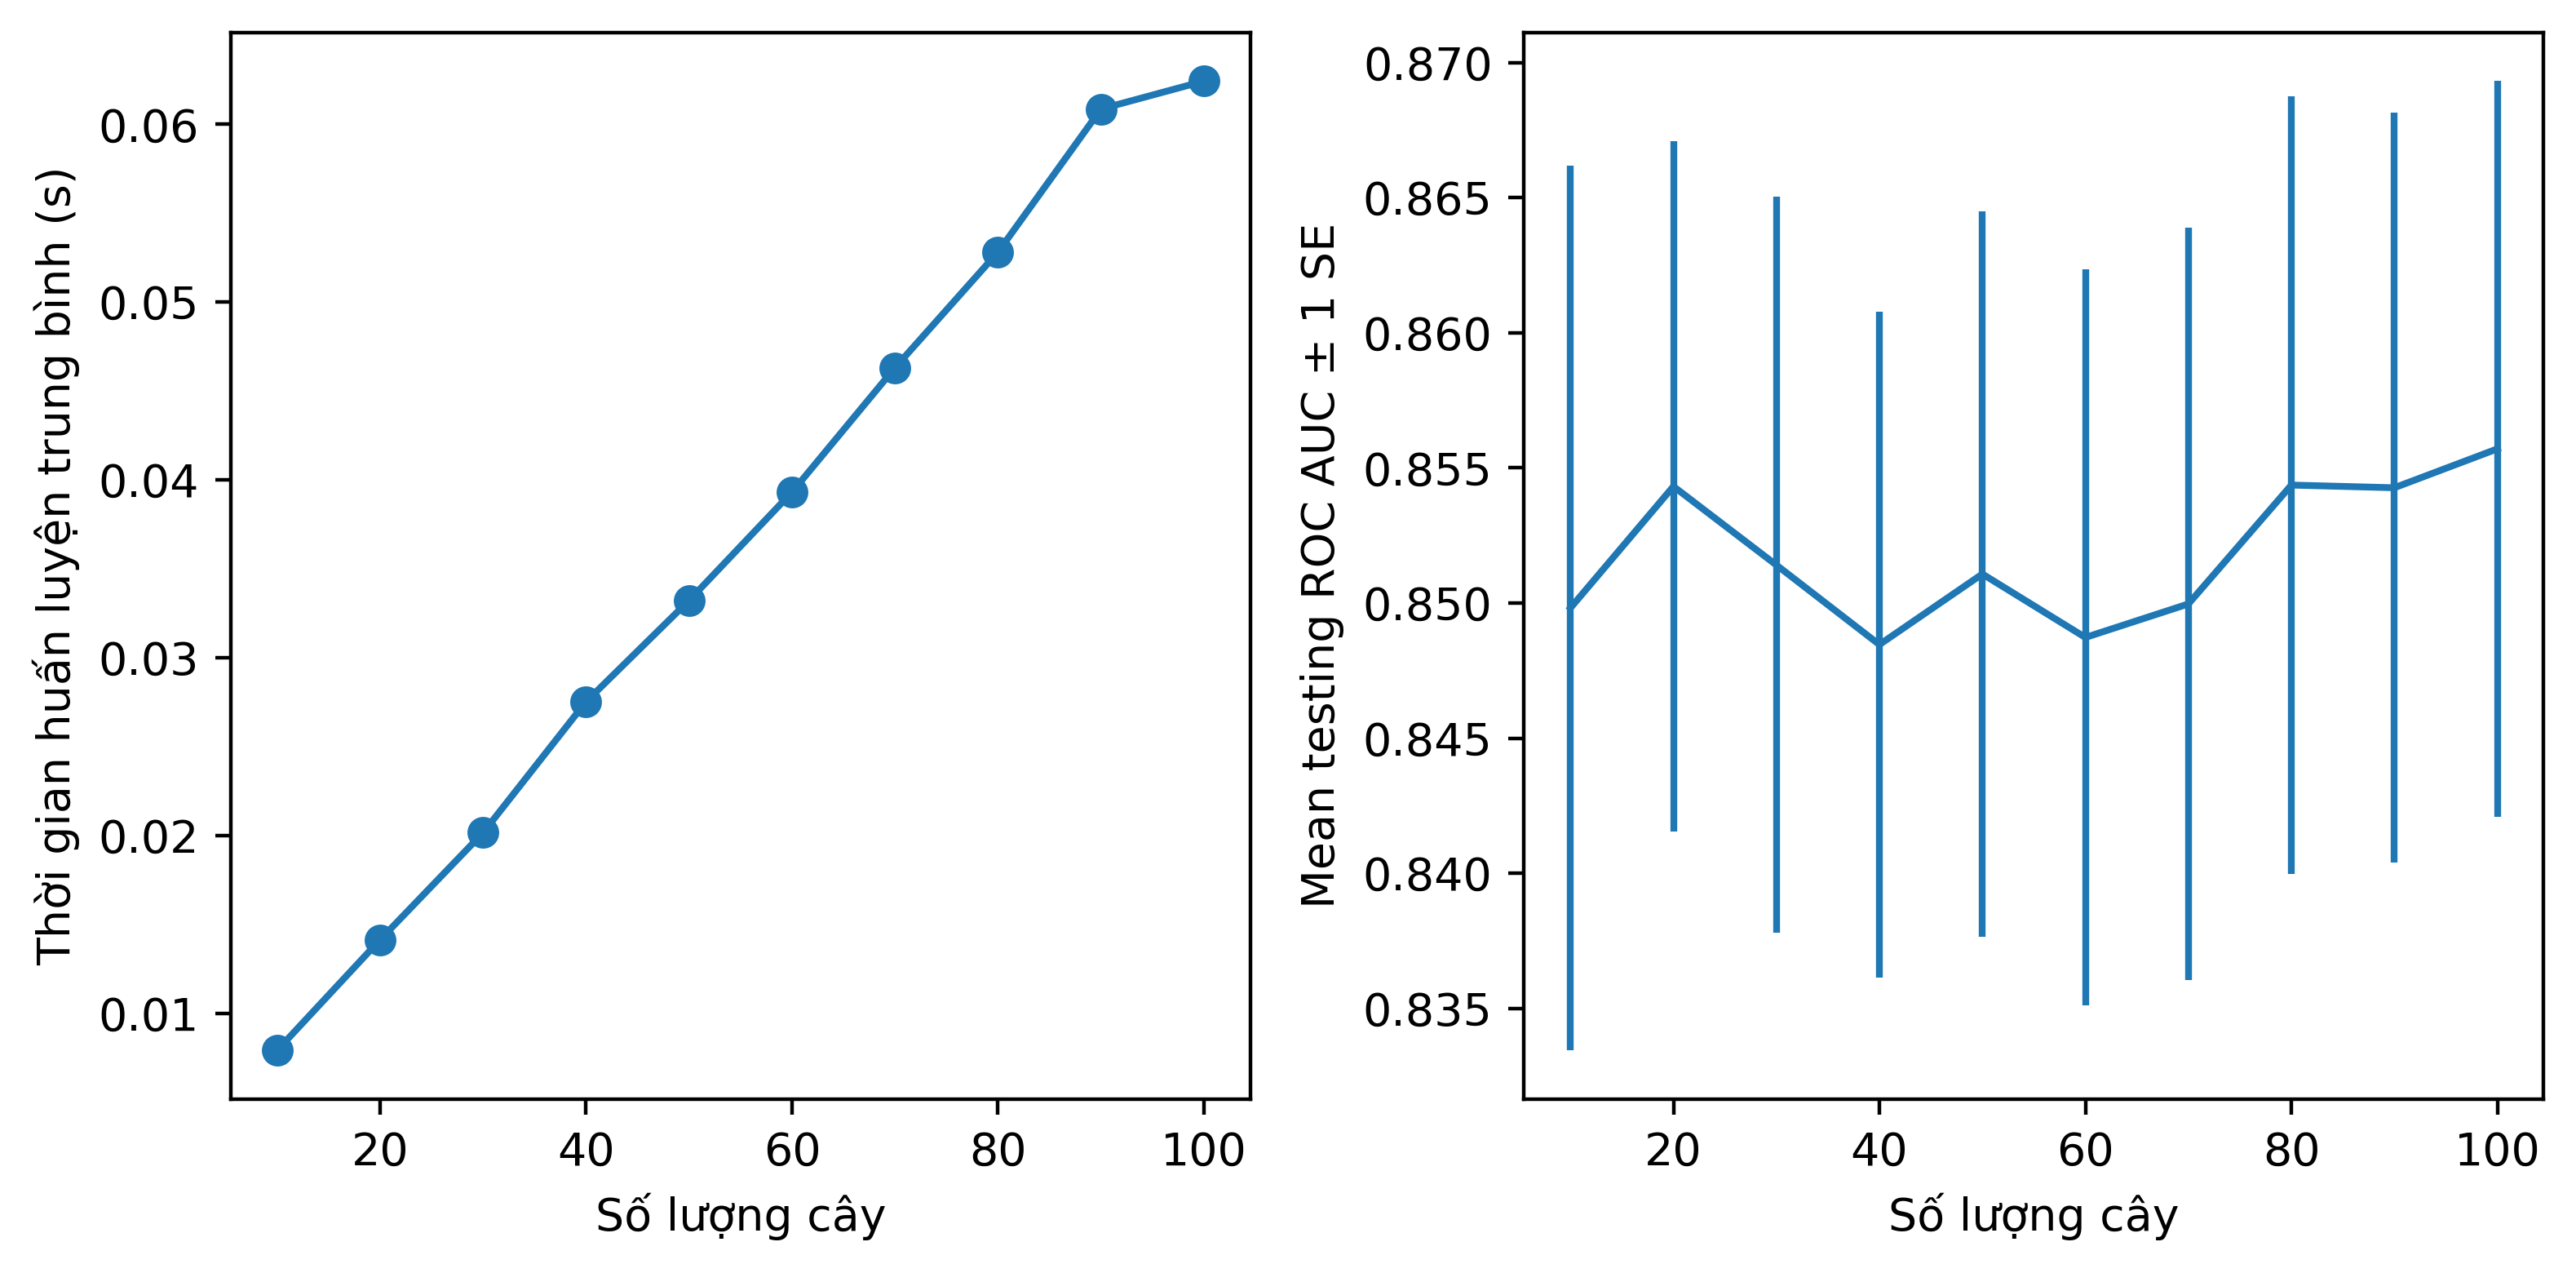

Best params: {'n_estimators': 100}


In [29]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
            cv_rf_ex_results_df['mean_fit_time'],
            '-o')
axs[0].set_xlabel('Số lượng cây')
axs[0].set_ylabel('Thời gian huấn luyện trung bình (s)')

axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
                cv_rf_ex_results_df['mean_test_score'],
                yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Số lượng cây')
axs[1].set_ylabel('Mean testing ROC AUC ± 1 SE')
plt.tight_layout()
plt.show()

print("Best params:", cv_rf_ex.best_params_)


5.Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham
số tốt nhất

<Axes: >

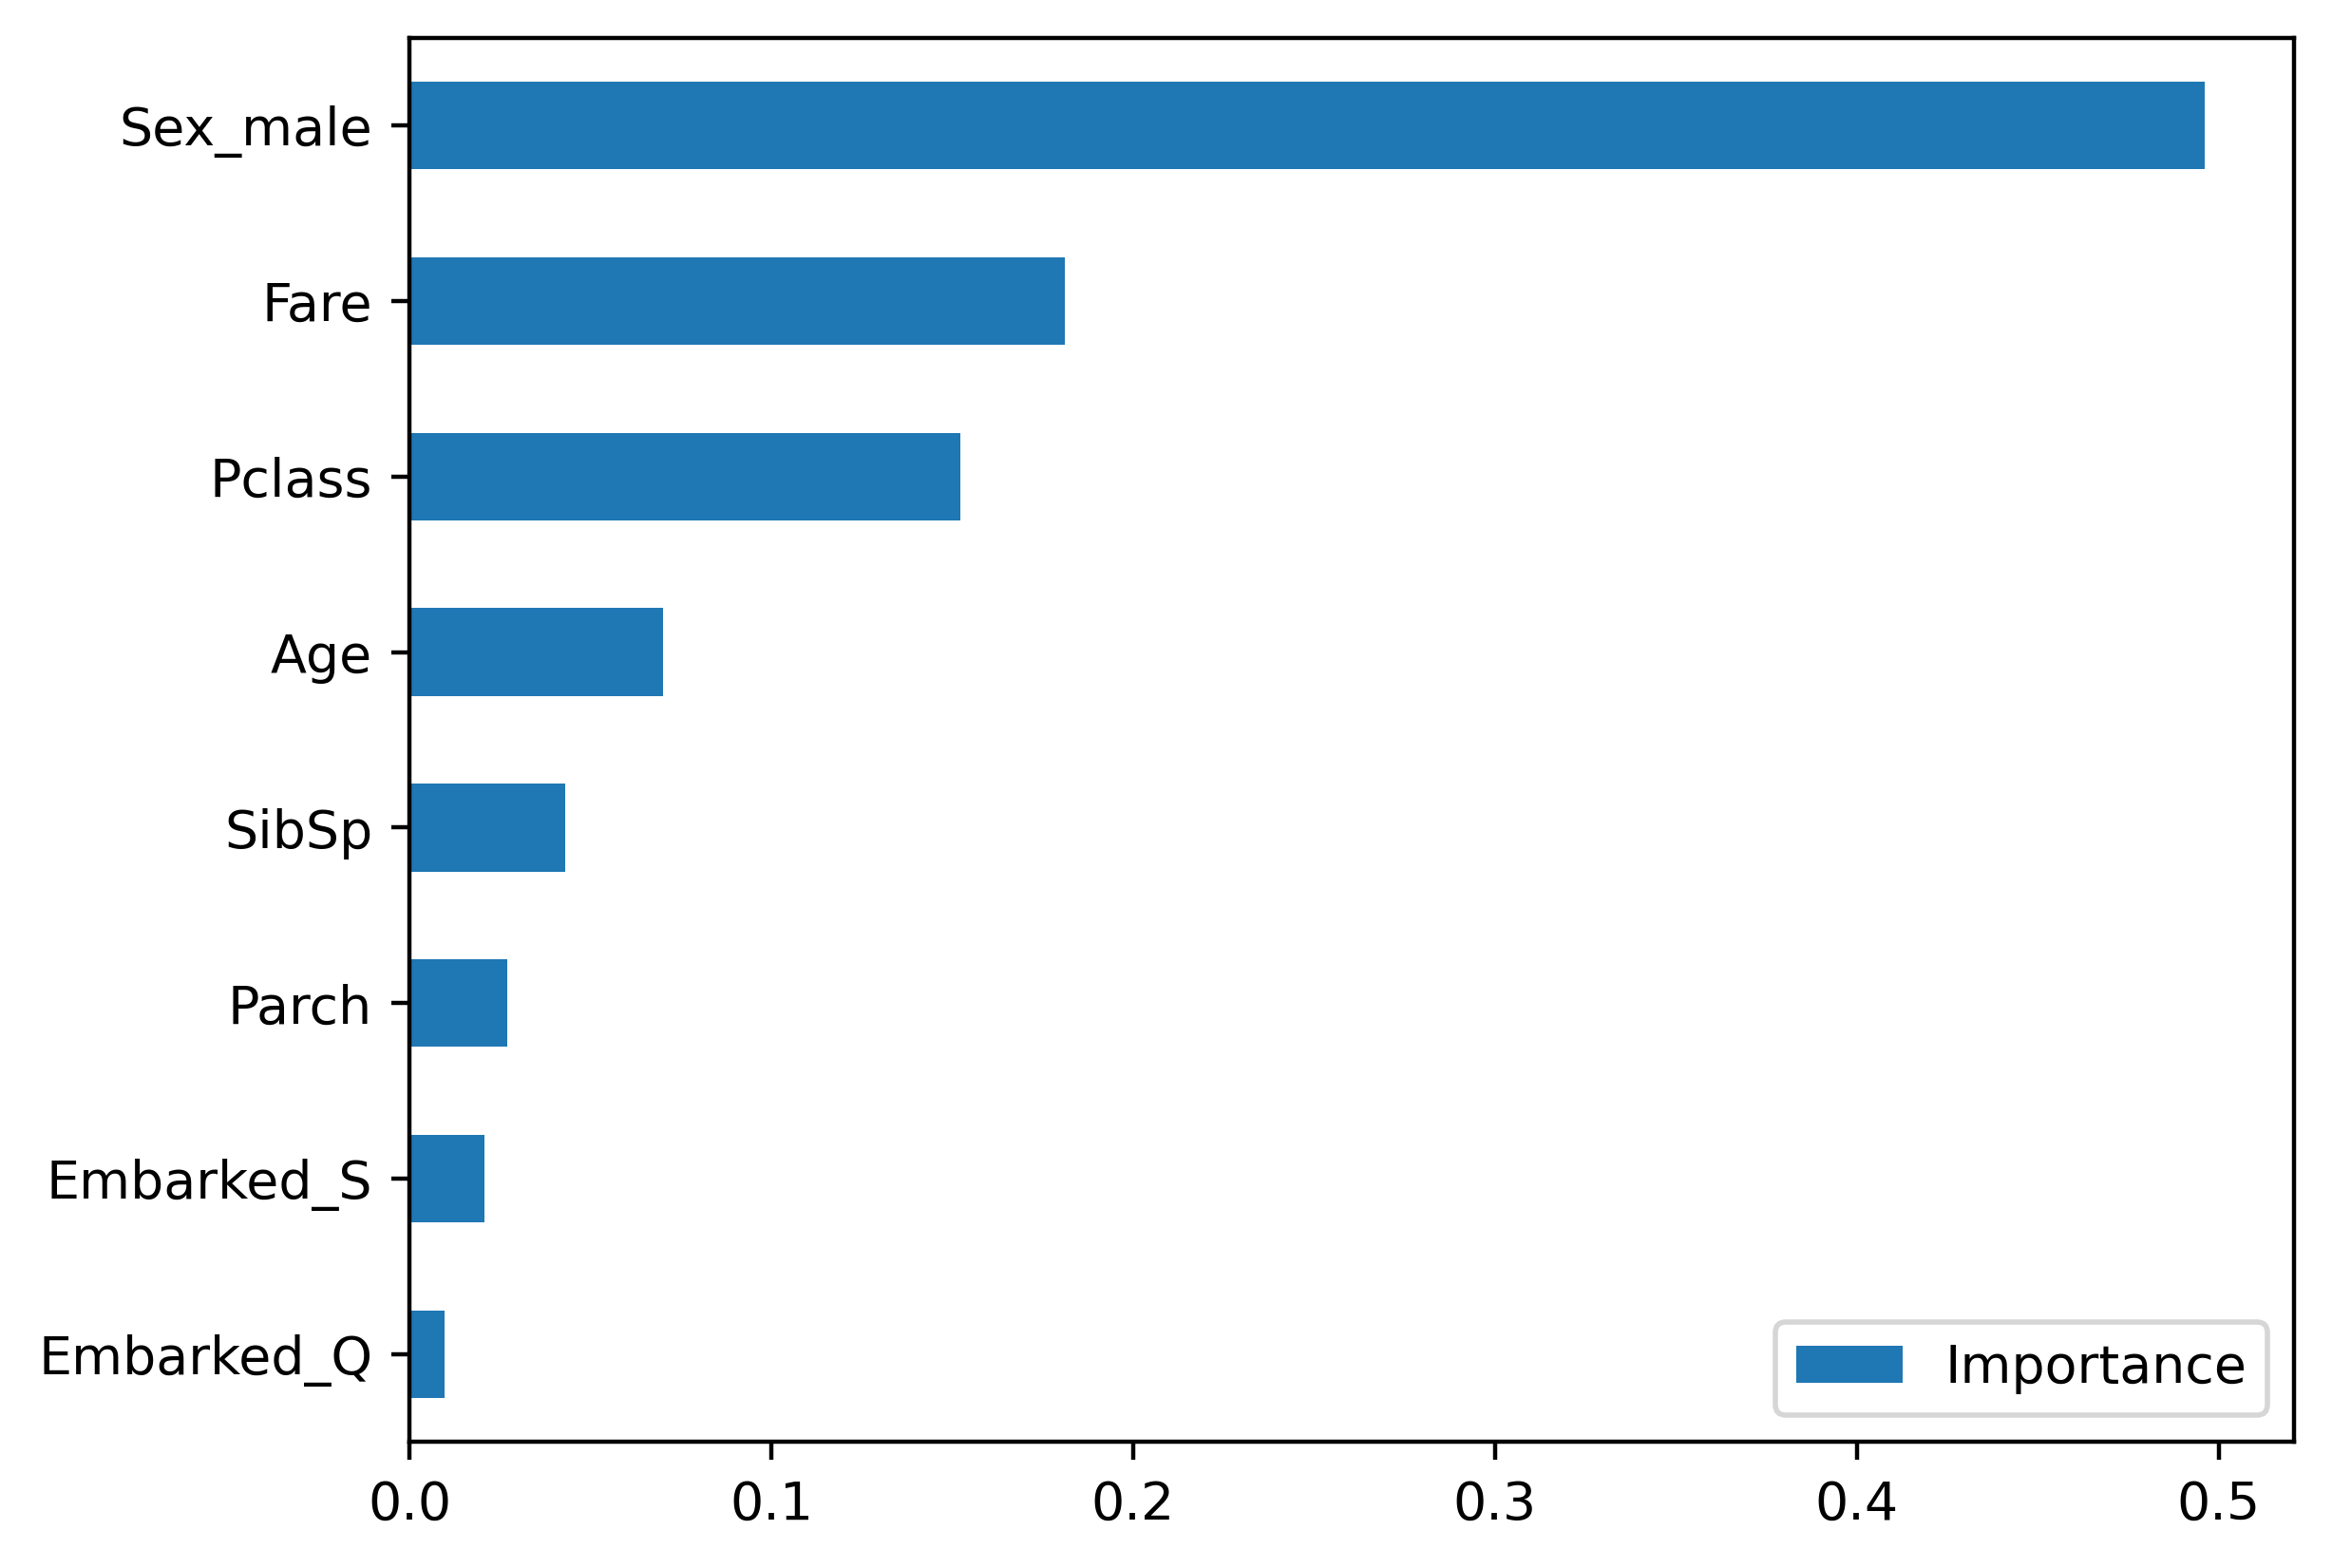

In [35]:
cv_rf_ex.best_params_
feat_imp_df = pd.DataFrame({
    'Importance': cv_rf_ex.best_estimator_.feature_importances_}, index=X.columns)

feat_imp_df.sort_values('Importance', ascending=True).plot.barh()


### **2.1.4. Bài tập thực hành 2**

Xây dựng cây quyết định và rừng cây trên dữ liệu bệnh tiểu đường. Dữ liệu lấy từ                                                           https://www.kaggle.com/code/tumpanjawatdiabetes-eda-random-forest-hp

**Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn**

1.Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [46]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

2.Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải
quyết

In [47]:
# Đọc dữ liệu
df = pd.read_csv("C:/Users/Admin/OneDrive/Documents/bt ptdl/bt_tuan_ptdl/da06_baitoanphanlop_Nguyễn Hoàng Thanh Tâm_3122410371/diabetes_prediction_dataset.csv")
# 2. Mã hoá các biến phân loại thành số
df = pd.get_dummies(df, drop_first=True)
features_response = df.columns.tolist()
# Loại bỏ cột mục tiêu ra khỏi danh sách feature
items_to_remove = ['diabetes']
features_response = [item for item in features_response if item not in items_to_remove]
features_response

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'gender_Male',
 'gender_Other',
 'smoking_history_current',
 'smoking_history_ever',
 'smoking_history_former',
 'smoking_history_never',
 'smoking_history_not current']

3.Chuẩn bị dữ liệu cho tập train và tập test

In [48]:
from sklearn.model_selection import train_test_split
from sklearn import tree
X_train, X_test, y_train, y_test = train_test_split(
    df[features_response].values,
    df['diabetes'].values,
    test_size=0.2,
    random_state=24
)

4.Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn

In [49]:
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


5.Hiển thị cây quyết định với package graphviz

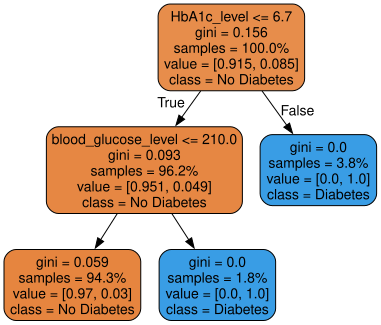

In [50]:
dot_data = tree.export_graphviz(
    dt,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=features_response,
    proportion=True,
    class_names=['No Diabetes', 'Diabetes']
)
graph = graphviz.Source(dot_data)
graph


**Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau**

1.Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

2.Tạo cây quyết định và xác định các giá trị tham số có thể chọn để tìm tham số tối ưu

In [51]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]}
dt = tree.DecisionTreeClassifier()

cv = GridSearchCV(
    dt,
    param_grid=params,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv.fit(X_train, y_train)


Fitting 4 folds for each of 7 candidates, totalling 28 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


3.Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

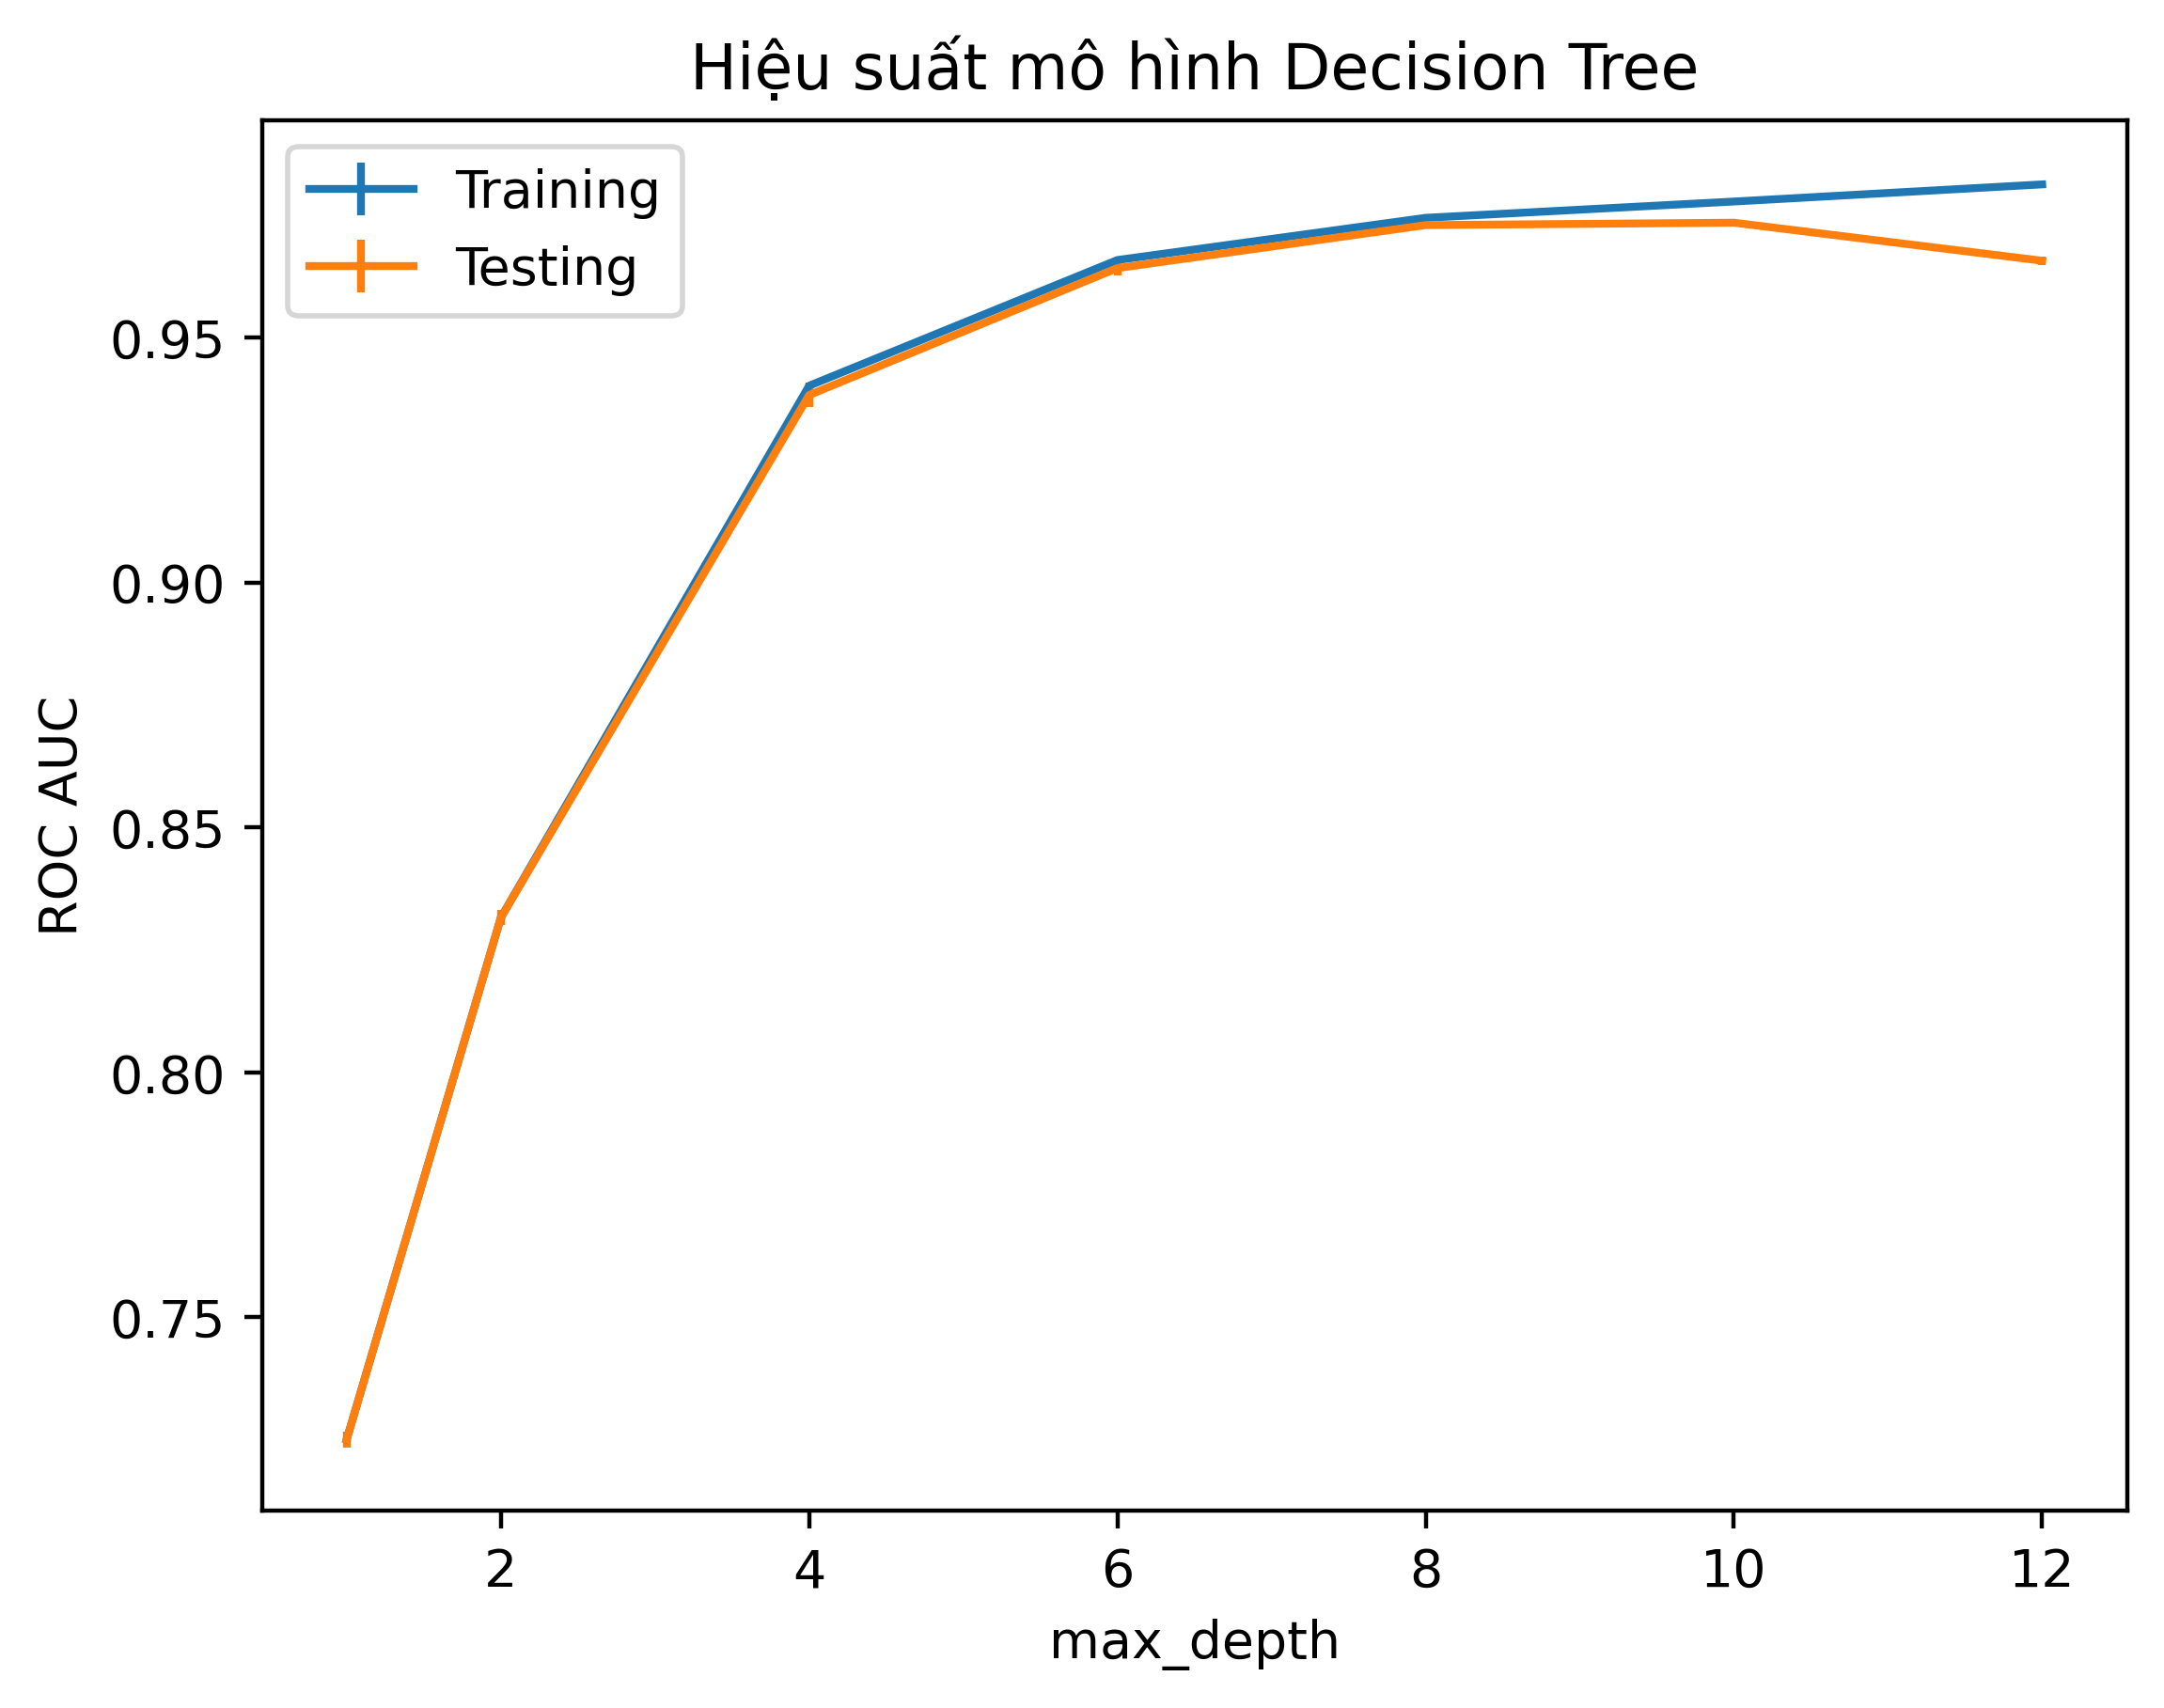

In [52]:
cv_results_df = pd.DataFrame(cv.cv_results_)
ax = plt.axes()

ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_train_score'],
            yerr=cv_results_df['std_train_score']/np.sqrt(4),
            label='Training')

ax.errorbar(cv_results_df['param_max_depth'],
            cv_results_df['mean_test_score'],
            yerr=cv_results_df['std_test_score']/np.sqrt(4),
            label='Testing')

ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Hiệu suất mô hình Decision Tree')
plt.show()


**Nhiệm vụ 3: Xây dựng rừng cây (random forest)**

1.Thực hiện 1, 2 và 3 như ở nhiệm vụ 1 để tải thư viện, nạp dữ liệu và chuẩn bị dữ liệu

2.Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=10,
    criterion='gini',
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=4
)


3.Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [54]:
rf_params_ex = {'n_estimators': list(range(10, 110, 10))}

cv_rf_ex = GridSearchCV(
    rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv_rf_ex.fit(X_train, y_train)


Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,10


4.Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

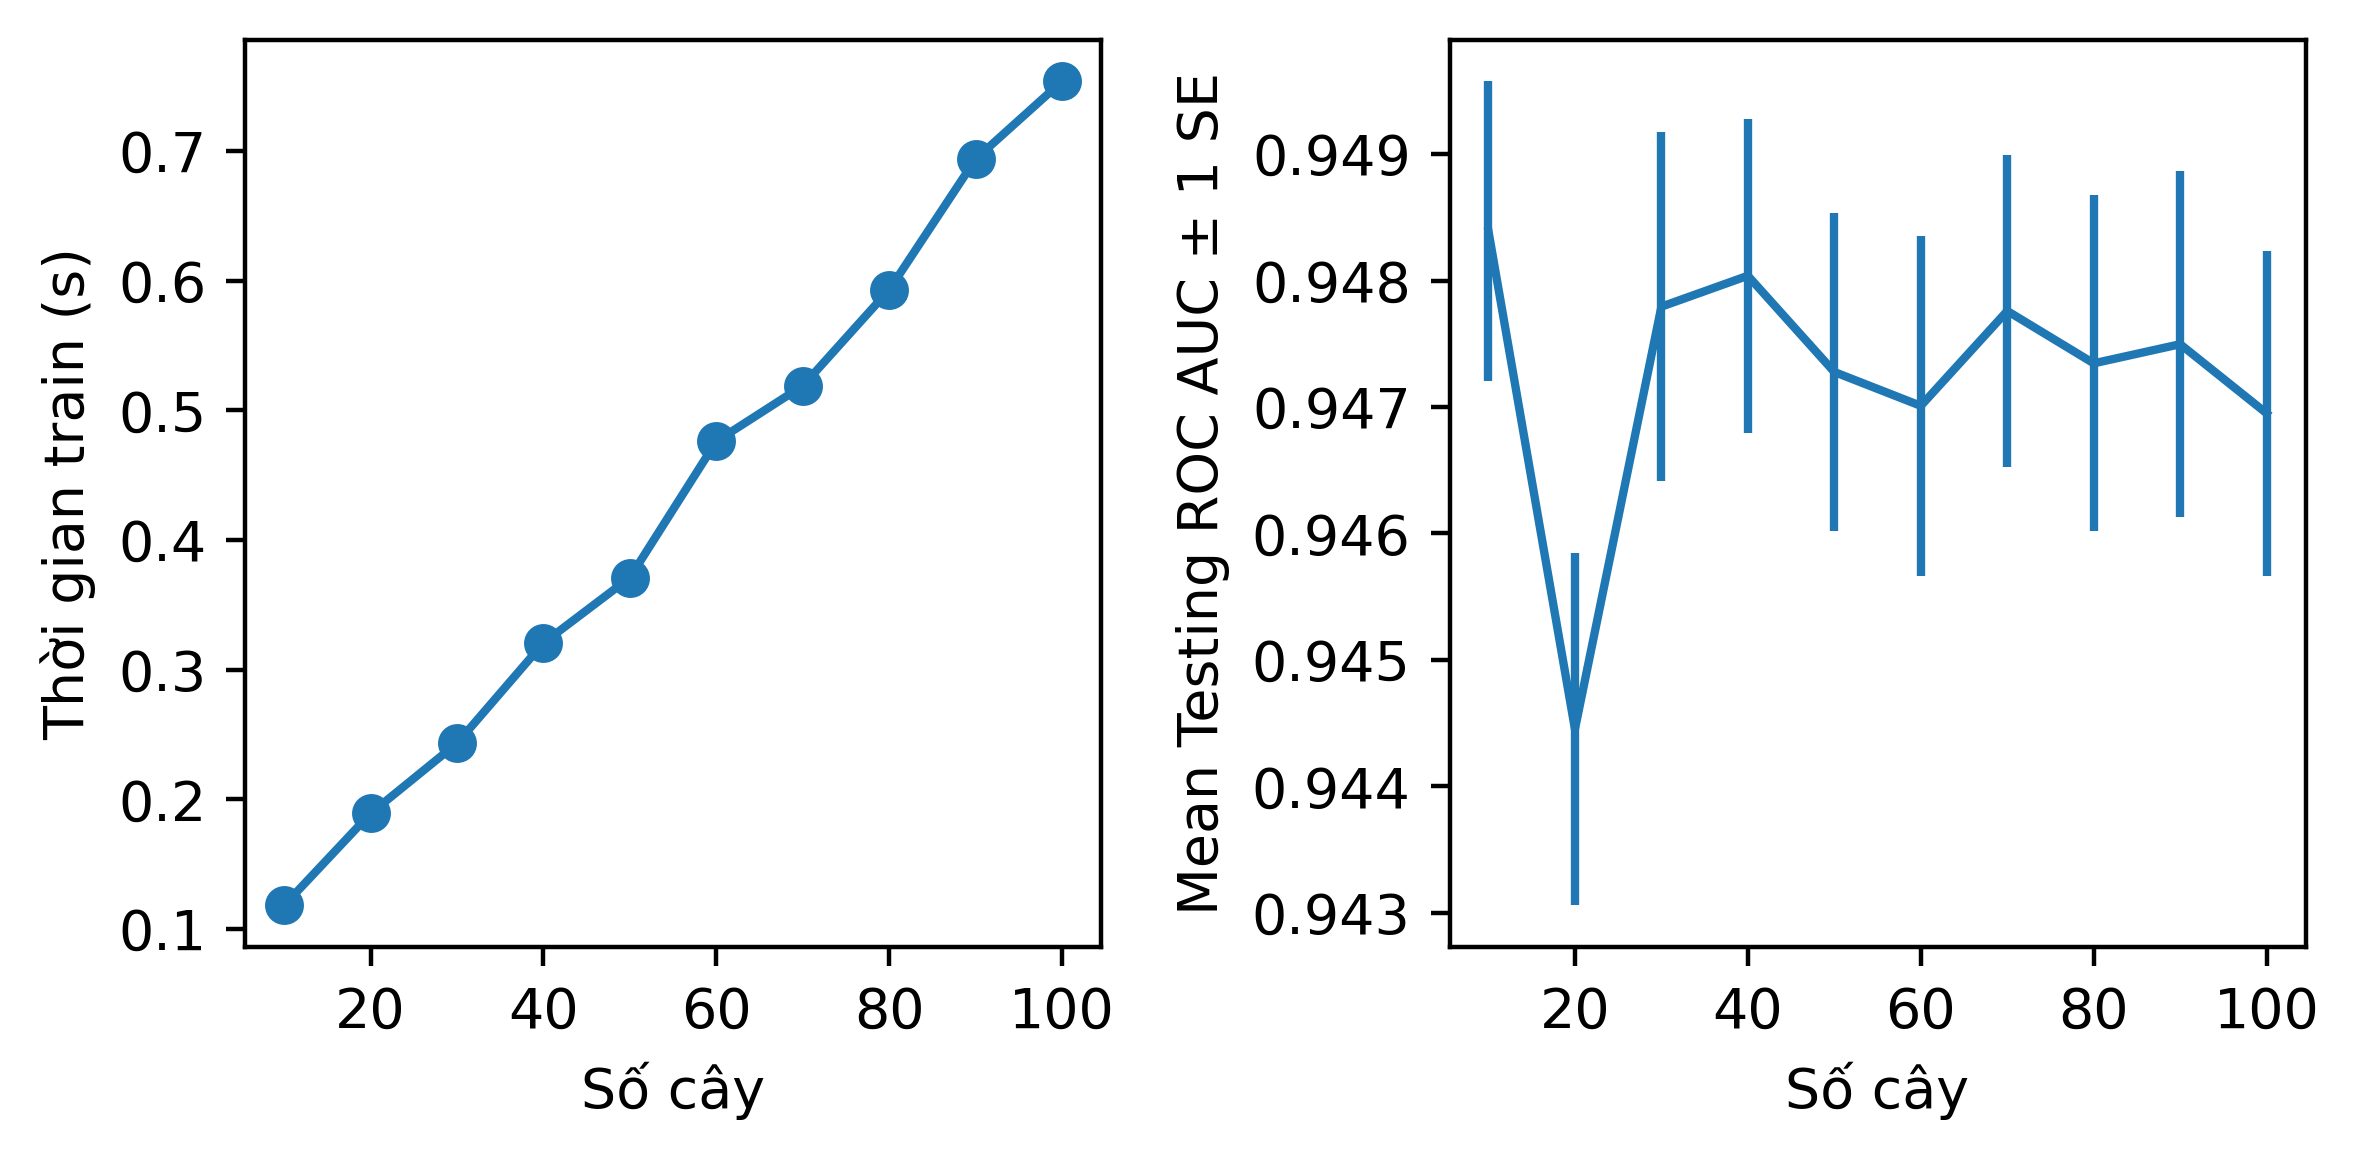

In [55]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

fig, axs = plt.subplots(1, 2, figsize=(6, 3))

# Thời gian huấn luyện
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
            cv_rf_ex_results_df['mean_fit_time'], '-o')
axs[0].set_xlabel('Số cây')
axs[0].set_ylabel('Thời gian train (s)')

# Độ chính xác ROC AUC
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
                cv_rf_ex_results_df['mean_test_score'],
                yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Số cây')
axs[1].set_ylabel('Mean Testing ROC AUC ± 1 SE')

plt.tight_layout()
plt.show()


5.Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham
số tốt nhất

Best Parameters: {'n_estimators': 10}


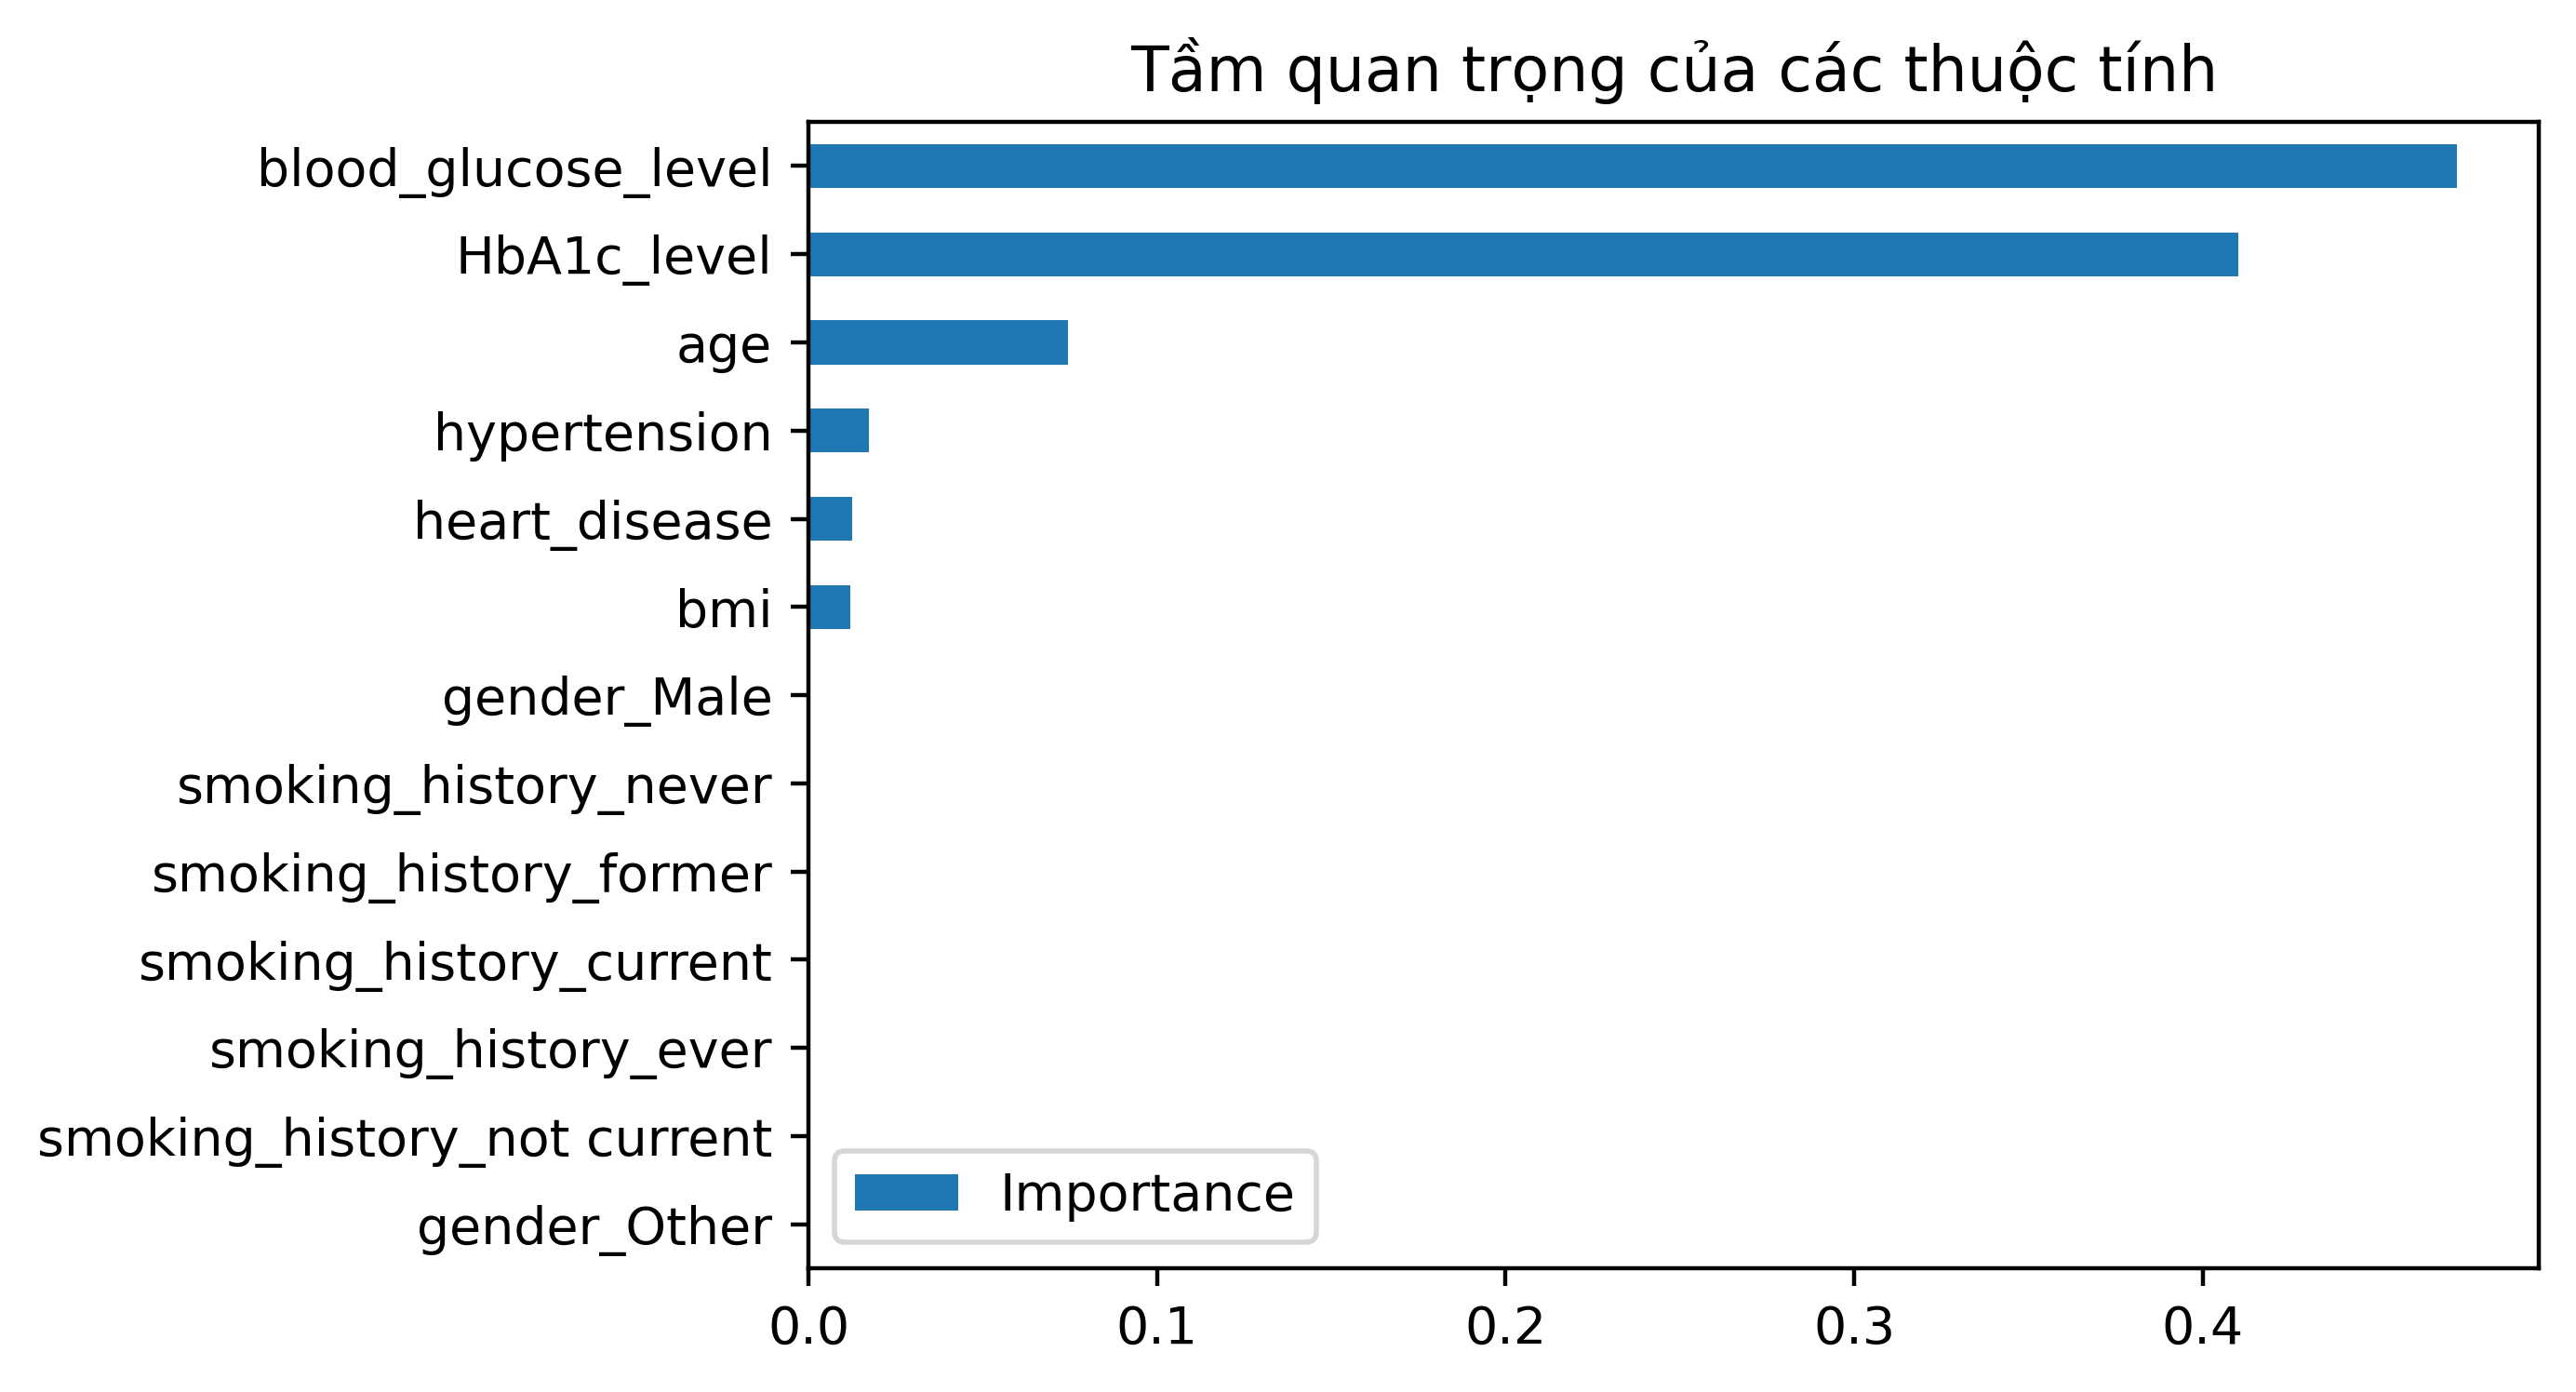

In [56]:
print("Best Parameters:", cv_rf_ex.best_params_)

feat_imp_df = pd.DataFrame({
    'Importance': cv_rf_ex.best_estimator_.feature_importances_
}, index=features_response)

feat_imp_df.sort_values('Importance', ascending=True).plot.barh(figsize=(6,4))
plt.title('Tầm quan trọng của các thuộc tính')
plt.show()
